# House Price Prediction Using Linear Regression

## Problem Statement
Estimating house prices manually can be difficult because property prices depend on multiple factors. This project aims to develop a machine learning model that can estimate house prices based on relevant housing and surrounding-area characteristics.

## Business Objective
The objective of this project is to build a Linear Regression model that provides quick and data-driven house price estimates. The model can serve as a preliminary price estimation tool for buyers, sellers, and real-estate professionals.

## Dataset
USA Housing Dataset

## Model
Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Dataset/USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
df.shape

(5000, 7)

In [4]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 499.6 KB


In [6]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


### Observation

The dataset contains 5000 records. All the main input features and the target `Price` are numerical, while `Address` is text data.

From the statistical summary, both Price and Area Population have positive minimum values, so no obvious negative values are visible. The dataset will be checked further during data cleaning.

In [7]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

### Observation

No missing values or duplicate records were found in the dataset. Therefore, no rows need to be removed or filled for these issues.

### Removing Unnecessary Column and Renaming Features

The `Address` column is removed because it contains free-text data and is not directly useful for the basic Linear Regression model.

The remaining columns are renamed to shorter names for easier coding.

In [9]:
df = df.drop("Address",axis=1)
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [10]:
df = df.rename(columns={
    "Avg. Area Income": "income",
    "Avg. Area House Age": "house_age",
    "Avg. Area Number of Rooms": "rooms",
    "Avg. Area Number of Bedrooms": "bedrooms",
    "Area Population": "population",
    "Price": "price"
})

df.head()

,income,house_age,rooms,bedrooms,population,price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [11]:
df.columns

Index(['income', 'house_age', 'rooms', 'bedrooms', 'population', 'price'], dtype='str')

In [12]:
print("Invalid prices:", (df["price"] <= 0).sum())
print("Invalid population:", (df["population"] < 0).sum())

Invalid prices: 0
Invalid population: 0


### Data Cleaning Observation

No invalid Price or Population values were found. The dataset is now ready for Exploratory Data Analysis.

## Exploratory Data Analysis (EDA)

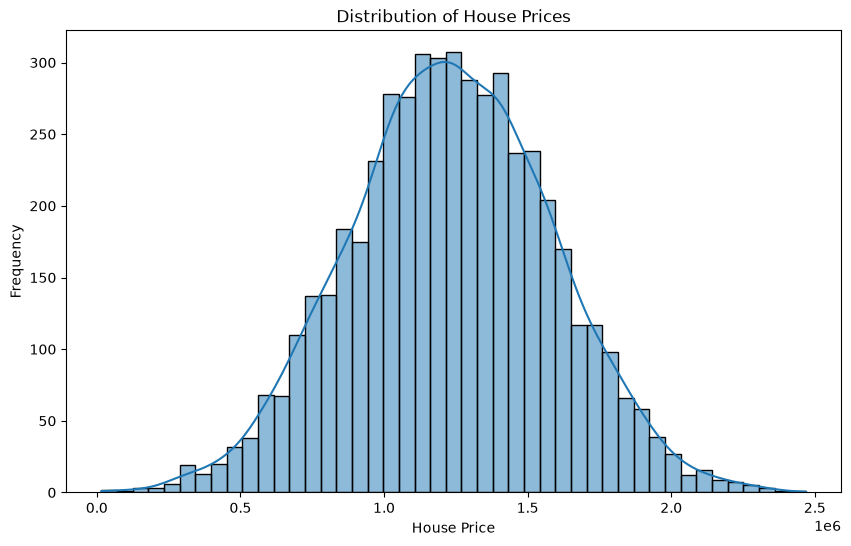

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.savefig(
    "../Images/price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
print("Price Skewness : ", df["price"].skew())

Price Skewness :  -0.002718064933559366


### Observation

The Price distribution is approximately symmetric and bell-shaped. The skewness value is approximately -0.003, which is very close to 0.

Therefore, there is no significant skewness in the target variable, and a log transformation of Price is not necessary for this basic model.

In [15]:
correlation = df.corr()

correlation

,income,house_age,rooms,bedrooms,population,price
income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734
house_age,-0.002007,1.000000,-0.009428,0.006149,-0.018743,0.452543
rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664
bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022168,0.171071
population,-0.016234,-0.018743,0.002040,-0.022168,1.000000,0.408556
price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000


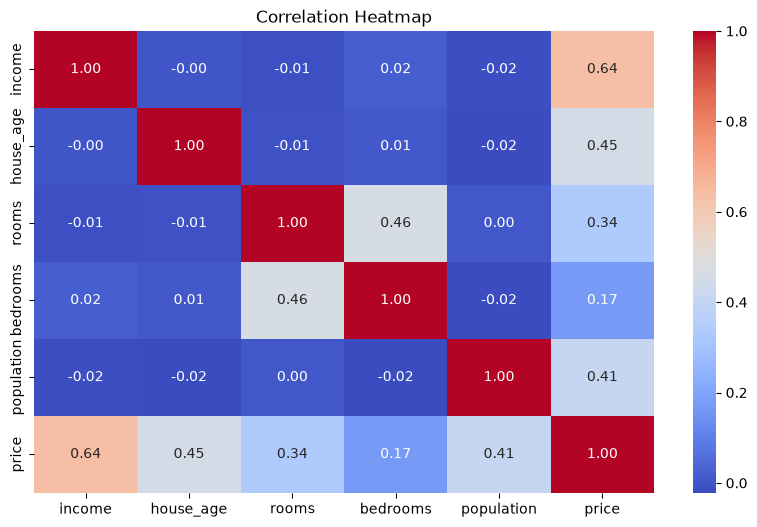

In [16]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../Images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

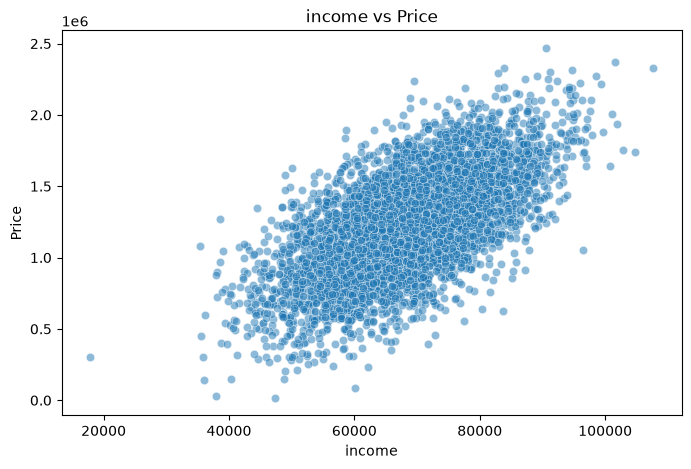

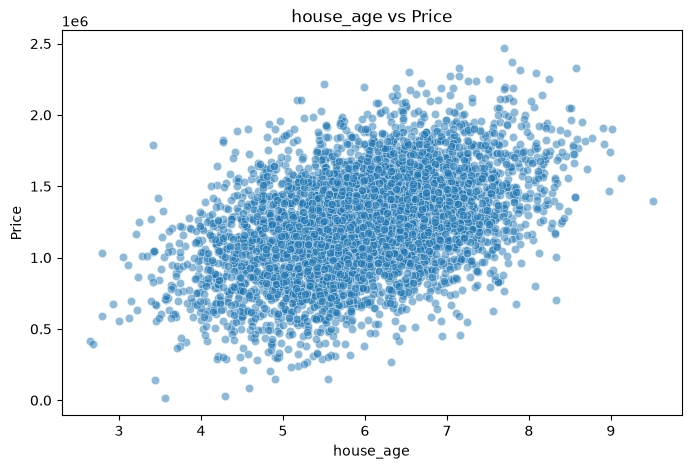

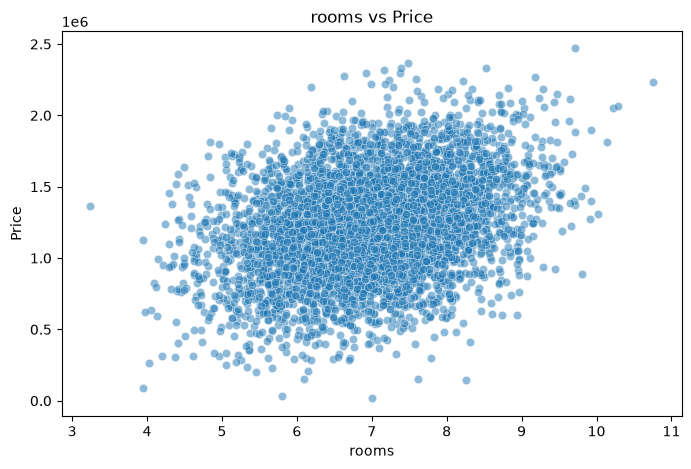

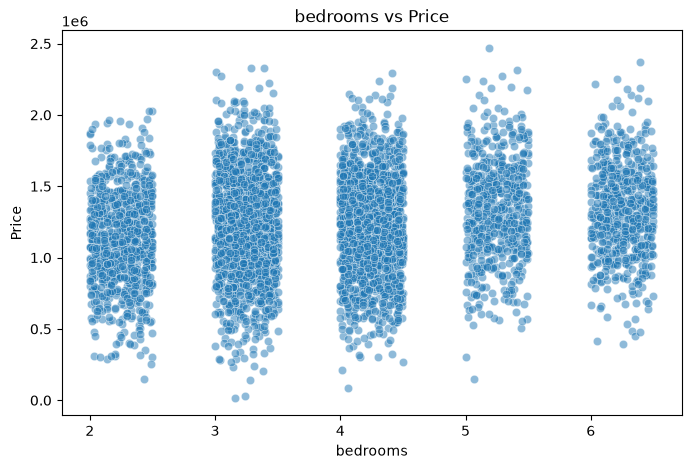

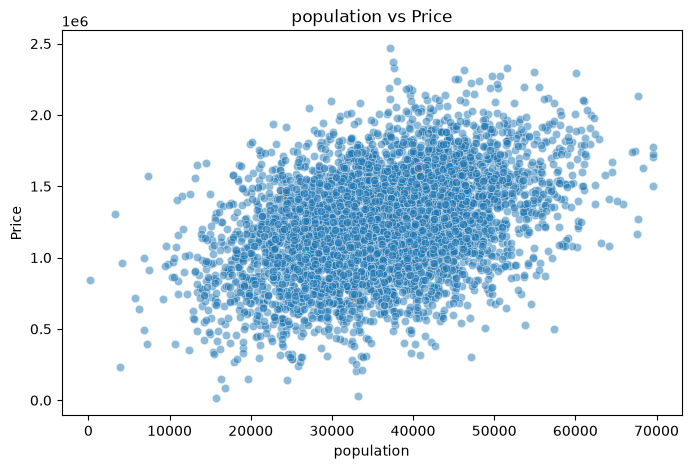

In [17]:
features = [
    "income",
    "house_age",
    "rooms",
    "bedrooms",
    "population"
]

for feature in features:
    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=feature,
        y="price",
        alpha=0.5
    )

    plt.title(f"{feature} vs Price")
    plt.xlabel(feature)
    plt.ylabel("Price")

    plt.show()

### Scatter Plot Observations

- **Income:** Shows a clear positive relationship with Price.
- **House Age:** Shows a positive relationship with Price, although the data points are more spread out.
- **Rooms:** Shows a positive relationship with Price.
- **Bedrooms:** Shows a comparatively weak relationship with Price.
- **Population:** Shows a positive relationship with Price.

Overall, most features show positive linear relationships with Price. However, Bedrooms appears to have a much weaker relationship with the target and will be investigated further during feature selection.

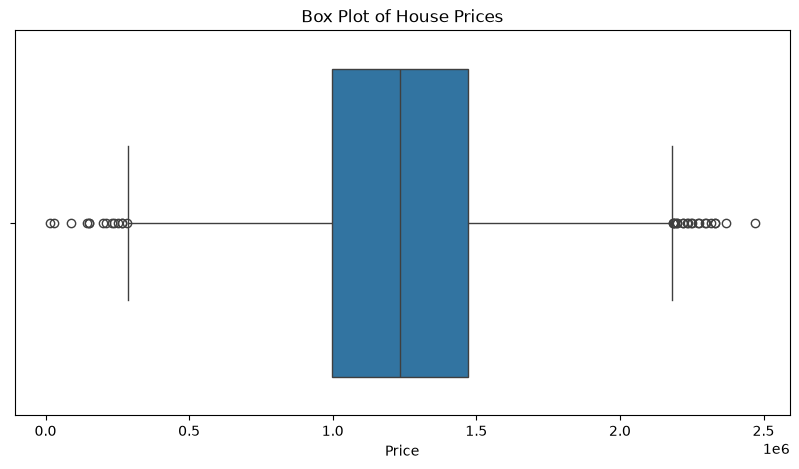

In [18]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["price"])

plt.title("Box Plot of House Prices")
plt.xlabel("Price")

plt.show()

In [19]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 997577.1350487601
Q3: 1471210.2042115545
IQR: 473633.0691627944
Lower Bound: 287127.5313045685
Upper Bound: 2181659.807955746


In [20]:
outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

print("Number of potential price outliers:", len(outliers))

outliers

Number of potential price outliers: 35


,income,house_age,rooms,bedrooms,population,price
90,48904.983269,4.844973,5.448956,3.38,32960.753070,2.018981e+05
256,91159.418327,6.536045,7.373851,3.01,54861.091097,2.298379e+06
263,40366.616291,4.902940,7.617118,5.07,16349.365394,1.520719e+05
355,87266.340225,8.248959,7.234261,5.00,45161.187677,2.249123e+06
465,90592.469609,7.700132,9.708803,5.19,37223.876167,2.469066e+06
622,90890.485814,7.510171,7.595487,6.21,45519.256271,2.252243e+06
693,107701.748378,7.143522,8.518608,3.29,37619.439929,2.332111e+06
696,49851.134784,4.684996,5.259695,3.04,32511.846268,2.832081e+05
715,92280.497474,7.258627,8.222633,4.31,38004.145211,2.237778e+06
901,89089.432075,7.146246,9.179994,5.29,49782.152070,2.271113e+06


### Observation

The box plot and IQR method identified 35 potential outliers in house prices, including both unusually low and unusually high prices.

These observations are not removed because they may represent genuine low-priced or high-priced houses rather than incorrect data.

In [21]:
df["population_category"] = pd.qcut(
    df["population"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df[["population", "population_category"]].head(10)

,population,population_category
0,23086.800503,Low
1,40173.072174,Medium
2,36882.159400,Medium
3,34310.242831,Medium
4,26354.109472,Low
5,26748.428425,Low
6,60828.249085,High
7,36516.358972,Medium
8,29387.396003,Low
9,40149.965749,Medium


In [22]:
df["population_category"].value_counts()


population_category
Low       1667
High      1667
Medium    1666
Name: count, dtype: int64

In [23]:
df.groupby(
    "population_category",
    observed=True
)["population"].agg(["min", "max", "mean"])

,min,max,mean
population_category,,,
Low,172.610686,31800.302253,25341.089360
Medium,31818.932565,40456.013364,36164.583726
High,40458.735870,69621.713378,46984.875670


### Observation

Population was divided into Low, Medium, and High categories with approximately equal numbers of records.

These categories are created only for model performance analysis and are not used as input features for training the Linear Regression model.

## Feature Selection

Exploratory analysis showed that the Bedrooms feature has a comparatively weak relationship with house price.

To determine whether the feature was necessary, Linear Regression performance was compared with and without Bedrooms while keeping the same train-test split and preprocessing steps.

Removing Bedrooms did not reduce model performance and resulted in a slight improvement in R², MAE, and RMSE. Therefore, Bedrooms was excluded from the final model to reduce unnecessary complexity.

The engineered `rooms_per_bedroom` feature used in an earlier version of the model was also removed because it provided very little additional predictive contribution.

## Model Preparation and Training

In [24]:
X = df[
    [
        "income",
        "house_age",
        "rooms",
        "population"
    ]
]

y = df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 4)
y shape: (5000,)


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 4)
Testing data: (1000, 4)


In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [28]:
pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).head()

,income,house_age,rooms,population
0,-0.190492,-0.128177,-0.131606,-0.827618
1,-1.388764,0.430804,0.800285,1.158299
2,-0.350124,0.466808,1.703751,-0.319043
3,-0.139098,0.114079,0.229733,-0.893752
4,0.622225,2.208957,0.435972,0.131301


### Observation

The input features were standardized using StandardScaler to bring them onto a similar scale. The scaler was fitted only on the training data and then applied to both the training and testing sets to avoid data leakage.

In [29]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Model training completed.")

Model training completed.


In [30]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,income,231822.626114
1,house_age,163616.244866
2,rooms,122117.363821
3,population,152187.969255


### Observation

Since the input features were standardized before training, their coefficient magnitudes can be compared to understand their relative influence on the model predictions.

- **Income** has the largest coefficient, indicating the strongest influence among the selected features.
- **House Age** has the second-largest coefficient.
- **Population** also shows a substantial contribution to the predicted price.
- **Number of Rooms** has the smallest coefficient among the final four features, but its contribution is still substantial.

Bedrooms and the engineered Rooms-per-Bedroom feature were excluded because their contribution was very small, and removing them did not reduce the model's predictive performance.

In [31]:
print("Intercept:", model.intercept_)

Intercept: 1229576.9925600903


### Observation

The coefficient values show the relative influence of the standardized input features on the model's predictions.

Among the final selected features, Income has the largest coefficient magnitude, indicating a strong relationship with predicted house prices.

Bedrooms and the engineered Rooms-per-Bedroom feature were excluded from the final model after feature analysis showed that removing them did not reduce predictive performance.

In [32]:
y_pred = model.predict(X_test_scaled)

In [33]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,1.339096e+06,1.309580e+06
1,1.251794e+06,1.238948e+06
2,1.340095e+06,1.247877e+06
3,1.431508e+06,1.229480e+06
4,1.042374e+06,1.066189e+06
5,1.555321e+06,1.546651e+06
6,1.250882e+06,1.096610e+06
7,1.039381e+06,8.313095e+05
8,8.324752e+05,7.862380e+05
9,1.420648e+06,1.470839e+06


## Model Evaluation

In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [35]:
r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R² Score: 0.9181214278738103
MAE: 80857.7894404619
RMSE: 100367.93130214656


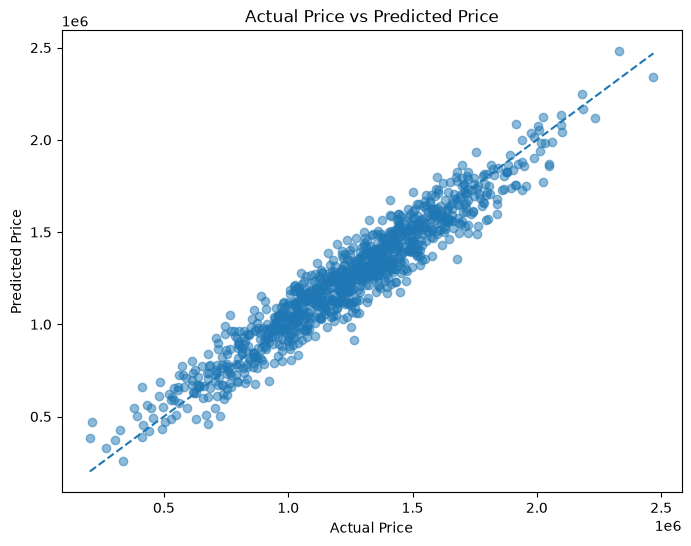

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.savefig(
    "../Images/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The Linear Regression model achieved an **R² score of approximately 0.9181**, indicating that the model explains about **91.81% of the variation in house prices**.

The model achieved a **Mean Absolute Error (MAE) of approximately 80,857.79**, which represents the average absolute difference between the actual and predicted house prices.

The **Root Mean Squared Error (RMSE) is approximately 100,367.93**. Since RMSE penalizes larger prediction errors more heavily, it provides additional insight into the magnitude of prediction errors.

Overall, the model demonstrates strong predictive performance using only the four selected features.

## Prediction Performance Across Population Categories

In [37]:
test_results = X_test.copy()

test_results["Actual Price"] = y_test
test_results["Predicted Price"] = y_pred

test_results["Population Category"] = df.loc[
    X_test.index, "population_category"
]

test_results.head()

,income,house_age,rooms,population,Actual Price,Predicted Price,Population Category
1501,61907.593345,7.017838,6.440256,43828.947207,1.339096e+06,1.309580e+06,High
2586,57160.202243,6.893260,6.921532,43467.147035,1.251794e+06,1.238948e+06,High
2653,70190.796445,6.745054,6.662567,29215.136112,1.340095e+06,1.247877e+06,Low
1055,69316.796889,6.300409,7.873576,24448.211461,1.431508e+06,1.229480e+06,Low
705,72991.481649,3.412866,6.494081,50626.495426,1.042374e+06,1.066189e+06,High


In [38]:
test_results["Absolute Error"] = abs(
    test_results["Actual Price"] - test_results["Predicted Price"]
)

test_results[[
    "Actual Price",
    "Predicted Price",
    "Population Category",
    "Absolute Error"
]].head(10)

,Actual Price,Predicted Price,Population Category,Absolute Error
1501,1.339096e+06,1.309580e+06,High,29516.062793
2586,1.251794e+06,1.238948e+06,High,12846.431398
2653,1.340095e+06,1.247877e+06,Low,92217.690017
1055,1.431508e+06,1.229480e+06,Low,202027.616845
705,1.042374e+06,1.066189e+06,High,23815.065951
106,1.555321e+06,1.546651e+06,High,8669.401081
589,1.250882e+06,1.096610e+06,Medium,154271.860801
2468,1.039381e+06,8.313095e+05,Medium,208071.231561
2413,8.324752e+05,7.862380e+05,Low,46237.232199
1600,1.420648e+06,1.470839e+06,Medium,50190.912784


In [39]:
category_performance = (
    test_results
    .groupby("Population Category", observed=True)["Absolute Error"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "MAE"})
)

category_performance

,count,MAE
Population Category,,
Low,323,80419.156073
Medium,338,81051.135401
High,339,81082.944729


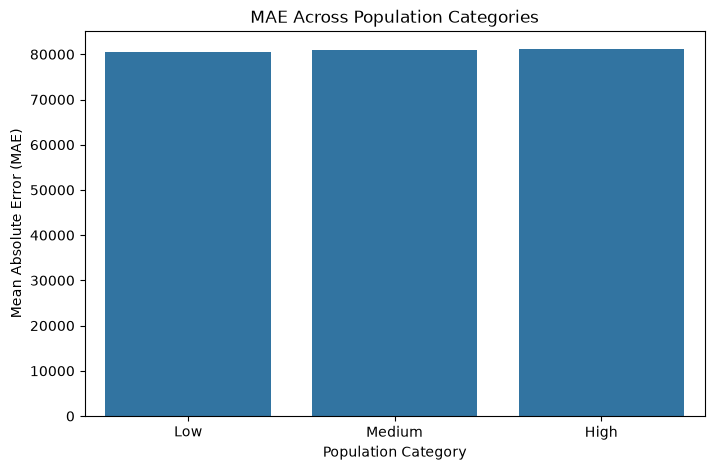

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_performance.reset_index(),
    x="Population Category",
    y="MAE",
    order=["Low", "Medium", "High"]
)

plt.title("MAE Across Population Categories")
plt.xlabel("Population Category")
plt.ylabel("Mean Absolute Error (MAE)")

plt.savefig(
    "../Images/population_category_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The model shows similar prediction errors across the Low, Medium, and High population categories.

The relatively small differences in MAE across the three groups indicate that the model maintains consistent prediction performance across different population levels.

## Final Results and Conclusion

### Final Model

The final Linear Regression model uses four input features:

- Income
- House Age
- Number of Rooms
- Population

Bedrooms and the engineered Rooms-per-Bedroom feature were excluded after feature analysis and model comparison showed that removing them did not reduce predictive performance.

### Model Performance

- **R² Score:** 0.9181
- **Mean Absolute Error (MAE):** 80,857.79
- **Root Mean Squared Error (RMSE):** 100,367.93

The model explains approximately **91.81% of the variation in house prices**.

### Conclusion

The final Linear Regression model provides strong predictive performance using a simplified set of four relevant features.

Feature selection reduced unnecessary model complexity while maintaining, and slightly improving, predictive performance.

The model was also evaluated using Actual vs Predicted analysis and prediction-error analysis across population categories to better understand its overall performance.

In [41]:
import joblib
import os

os.makedirs("../Model", exist_ok=True)

joblib.dump(model, "../Model/linear_regression_model.pkl")
joblib.dump(scaler, "../Model/scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
